# Checking the categories in the signal

### Setting up the data and tools

Lessons: 
  - Wrong sign sample cannot be used for the shape of the combinatorics as we still have double charm
  - Maybe we could cut tighter on the BDT_Iso

In [18]:
%run 'load-data.ipynb'

Building DAG of jobs...
Nothing to be done (all requested files are present and up to date).
Complete log: .snakemake/log/2023-10-25T110310.452124.snakemake.log
df_rs and df_ws are now available with the right sign and wrong sign data


In [90]:
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (15,6)

In [43]:
def mygroupby(d, groupbycols):
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g


In [45]:
def categ_groupby(df, groupbycol, threshold):
    """ Group the dataframe df by column groupbycol, grouping together entries rows with count < threshold """
    g = pd.DataFrame(df.groupby(groupbycol).count()["category"]).rename(columns={"category":"count"})
    g["Category"] = g.apply(lambda row: row.name if row["count"] > threshold else "others", axis=1)
    g2 = g.groupby("Category").sum()
    g2 = g2.sort_values([ 'count'], ascending=False)
    total = g2.sum()["count"]
    g2["Percentage"] = g2.apply(lambda row: 100 * row["count"]/total, axis=1)
    g2["cumulative %"] = g2["Percentage"].cumsum(axis = 0)
    return g, g2

In [46]:
bdt_cutval=0

## Loading RS data

This data already has cuts on q2_2 > 0 and B_M < 5000

In [47]:
print(df_rs.shape)

(233110, 42)


In [48]:
#_, c_rs = categ_groupby(df_rs, "key", 400)
# print(c_rs[['count', 'Percentage']].to_markdown())
# print()
# print(c_rs[['count', 'Percentage']].to_latex(float_format="%.2f", escape=True ))

In [49]:
# _, cs_rs = categ_groupby(df_rs, "simplified_key", 400)
# cs_rs

## Loading WS data

In [50]:
print(df_ws.shape)

(45300, 42)


## Comparing the simplified mappings between RS and WS

In [51]:
_, cs_rs = categ_groupby(df_rs, "simplified_key", 400)
cs_rs

,count,Percentage,cumulative %
Category,,,
Double Charm,204311,87.645747,87.645747
Bad Xc,20449,8.772253,96.418000
Signal,3562,1.528034,97.946034
Normalization like,2034,0.872549,98.818584
Combinatorial,1433,0.614731,99.433315
Tau from charm,1110,0.476170,99.909485
others,211,0.090515,100.000000


In [52]:
_, cs_ws = categ_groupby(df_ws, "simplified_key", 100)
cs_ws

,count,Percentage,cumulative %
Category,,,
Double Charm,38389,84.743929,84.743929
Bad Xc,5150,11.368653,96.112583
Combinatorial,1261,2.783664,98.896247
Normalization like,409,0.902870,99.799117
others,91,0.200883,100.000000


## Comparing the detailed mappings

In [53]:
categ_groupby(df_rs, "key", 400)[1]

,count,Percentage,cumulative %
Category,,,
Xc_signal_Ypis_displaced_fromBs_fromDs,47066,20.190468,20.190468
Xc_signal_Ypis_displaced_fromB0_fromDp,46669,20.020162,40.210630
Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB,35243,15.118614,55.329244
Xc_background,20449,8.772253,64.101497
Xc_signal_Ypis_displaced_fromBp_fromD0,18506,7.938741,72.040239
Xc_signal_Ypis_nomatch_doubleCharm,15667,6.720861,78.761100
Xc_signal_Ypis_displaced_fromBs_fromDp,10747,4.610270,83.371370
Xc_signal_Ypis_displaced_fromLambdab_fromLambdac,6433,2.759641,86.131011
Xc_signal_Ypis_displaced_fromBp_fromDp,5843,2.506542,88.637553


In [54]:
categ_groupby(df_ws, "key", 100)[1]

,count,Percentage,cumulative %
Category,,,
Xc_signal_Ypis_displaced_fromBp_fromD0,11642,25.699779,25.699779
Xc_signal_Ypis_nomatch_doubleCharm,6577,14.518764,40.218543
Xc_signal_Ypis_displaced_fromBs_fromDs,6115,13.498896,53.717439
Xc_background,5150,11.368653,65.086093
Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB,3066,6.768212,71.854305
Xc_signal_Ypis_displaced_fromB0_fromD0,2406,5.311258,77.165563
Xc_signal_Ypis_diffVertex_doubleCharm,2373,5.238411,82.403974
Xc_signal_Ypis_diffVertex_CharmStrange,2060,4.547461,86.951435
Xc_signal_Ypis_nomatch_charmStrange,1368,3.019868,89.971302


## Checking the Y mass

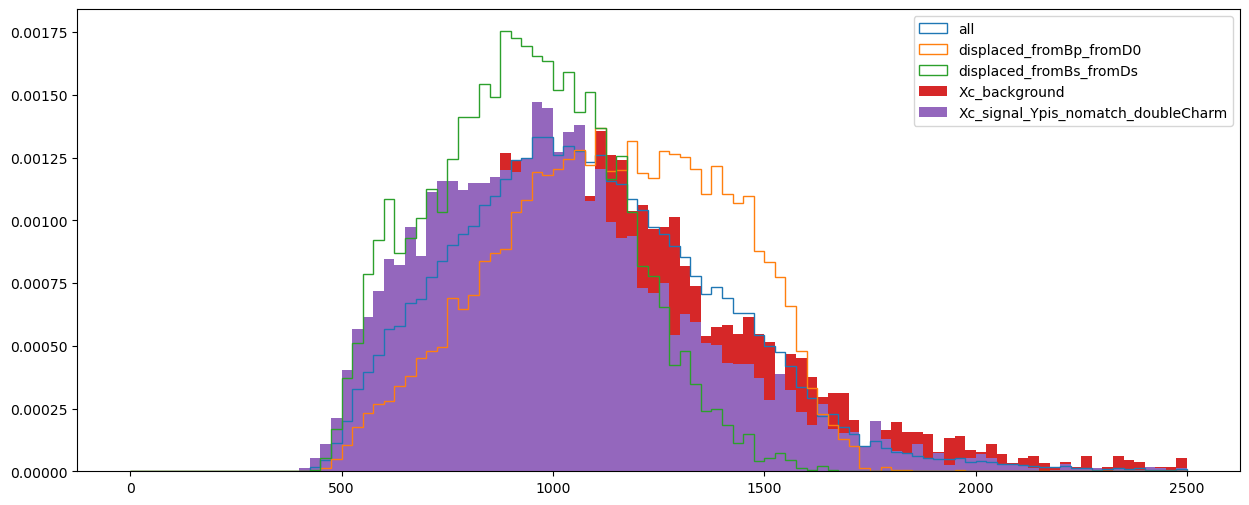

In [67]:
myrange=[0, 2500]
plt.hist(df_ws.Y_M, bins=100, 
         label= 'all', histtype='step', density=True, range=myrange);
plt.hist(df_ws.query("key == 'Xc_signal_Ypis_displaced_fromBp_fromD0'").Y_M, bins=100, 
         label= 'displaced_fromBp_fromD0', histtype='step', density=True, range=myrange)
plt.hist(df_ws.query("key == 'Xc_signal_Ypis_displaced_fromBs_fromDs'").Y_M, bins=100, 
         label= 'displaced_fromBs_fromDs', histtype='step', density=True, range=myrange)
plt.hist(df_ws.query("key == 'Xc_background'").Y_M, bins=100, 
         label= 'Xc_background', histtype='bar', density=True, range=myrange)
plt.hist(df_ws.query("key == 'Xc_signal_Ypis_nomatch_doubleCharm'").Y_M, bins=100, 
         label= 'Xc_signal_Ypis_nomatch_doubleCharm', histtype='bar', density=True, range=myrange)
plt.legend();

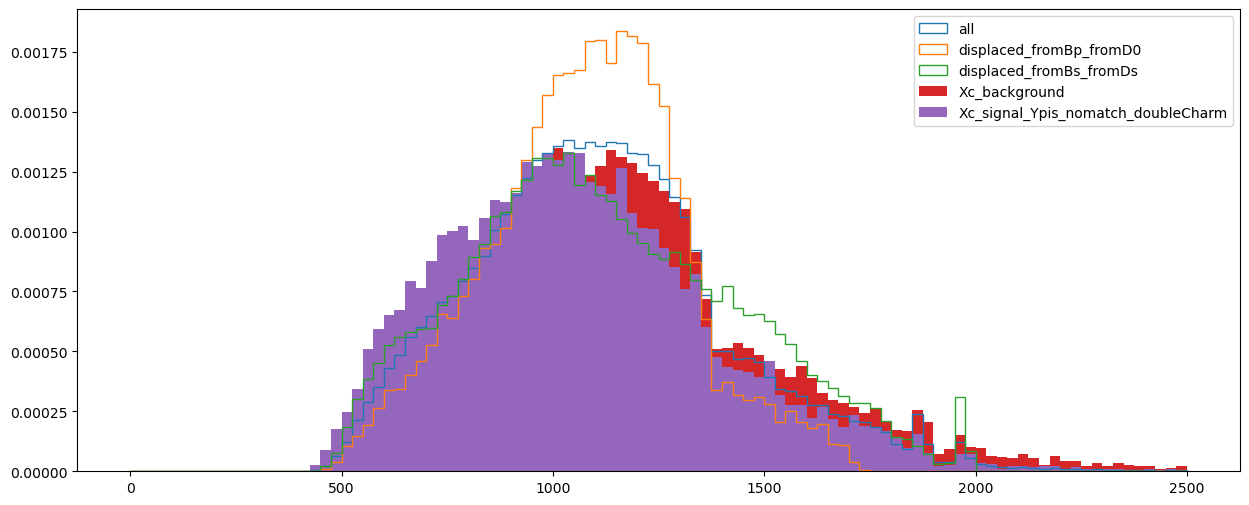

In [68]:
plt.hist(df_rs.Y_M, bins=100, 
         label= 'all', histtype='step', density=True, range=myrange);
plt.hist(df_rs.query("key == 'Xc_signal_Ypis_displaced_fromBp_fromD0'").Y_M, bins=100, 
         label= 'displaced_fromBp_fromD0', histtype='step', density=True, range=myrange)
plt.hist(df_rs.query("key == 'Xc_signal_Ypis_displaced_fromBs_fromDs'").Y_M, bins=100, 
         label= 'displaced_fromBs_fromDs', histtype='step', density=True, range=myrange)
plt.hist(df_rs.query("key == 'Xc_background'").Y_M, bins=100, 
         label= 'Xc_background', histtype='bar', density=True, range=myrange)
plt.hist(df_rs.query("key == 'Xc_signal_Ypis_nomatch_doubleCharm'").Y_M, bins=100, 
         label= 'Xc_signal_Ypis_nomatch_doubleCharm', histtype='bar', density=True, range=myrange)
plt.legend();

# Checking Isolation BDT response

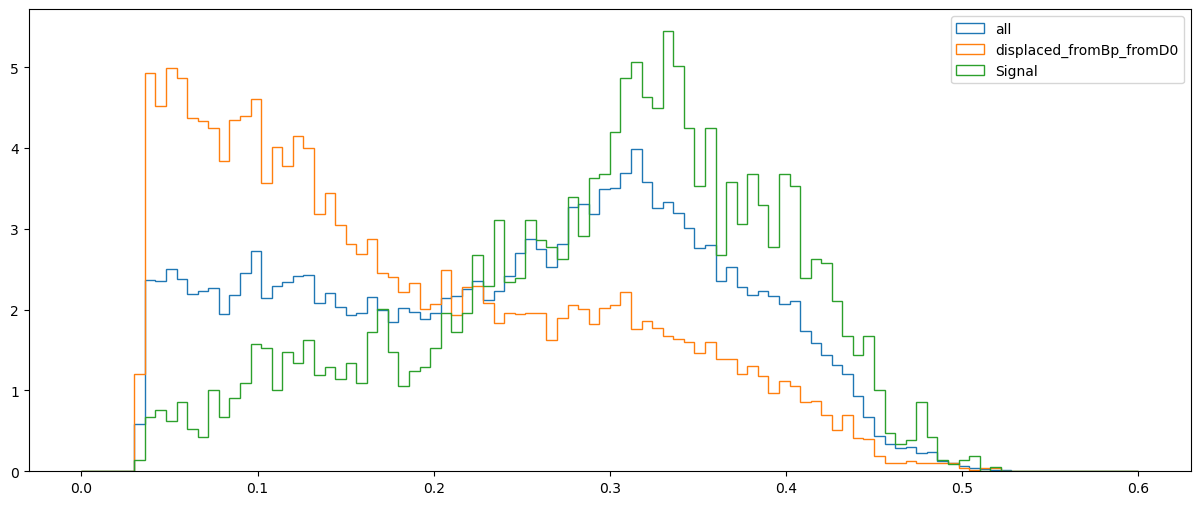

In [75]:
isorange=[0, 0.6]
plt.hist(df_rs.BDT_Iso, bins=100, 
         label= 'all', histtype='step', density=True, range=isorange);
plt.hist(df_rs.query("key == 'Xc_signal_Ypis_displaced_fromBp_fromD0'").BDT_Iso, bins=100, 
         label= 'displaced_fromBp_fromD0', histtype='step', density=True, range=isorange)
plt.hist(df_rs.query("key == 'Xc_signal_Ypis_displaced_fromBs_fromTau'").BDT_Iso, bins=100, 
         label= 'Signal', histtype='step', density=True, range=isorange)
plt.legend();

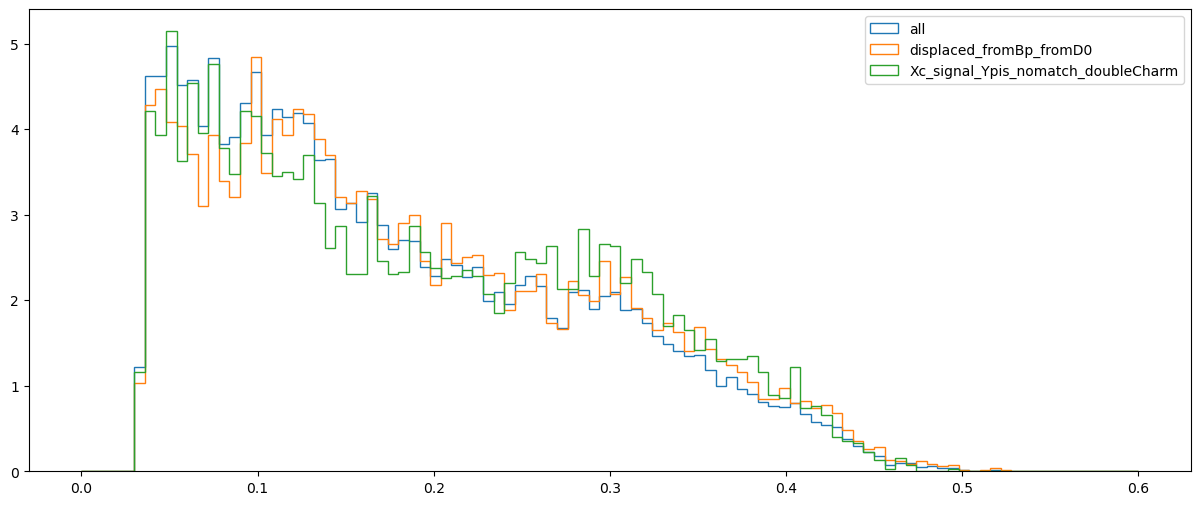

In [76]:
isorange=[0, 0.6]
plt.hist(df_ws.BDT_Iso, bins=100, 
         label= 'all', histtype='step', density=True, range=isorange);
plt.hist(df_ws.query("key == 'Xc_signal_Ypis_displaced_fromBp_fromD0'").BDT_Iso, bins=100, 
         label= 'displaced_fromBp_fromD0', histtype='step', density=True, range=isorange)
plt.hist(df_ws.query("key == 'Xc_signal_Ypis_nomatch_doubleCharm'").BDT_Iso, bins=100, 
         label= 'Xc_signal_Ypis_nomatch_doubleCharm', histtype='step', density=True, range=isorange)
plt.legend();

## Applying a tigher cut on BDT_Iso and checking category split

In [78]:
isocutval = 0.2
df_rs_isocut = df_rs.query(f"BDT_Iso > {isocutval}")
df_ws_isocut = df_ws.query(f"BDT_Iso > {isocutval}")

In [79]:
categ_groupby(df_rs_isocut, "key", 400)[1]

,count,Percentage,cumulative %
Category,,,
Xc_signal_Ypis_displaced_fromB0_fromDp,33960,22.893970,22.893970
Xc_signal_Ypis_displaced_fromBs_fromDs,30315,20.436711,43.330682
Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB,25667,17.303284,60.633966
Xc_background,11978,8.074911,68.708877
Xc_signal_Ypis_nomatch_doubleCharm,8563,5.772705,74.481582
Xc_signal_Ypis_displaced_fromBs_fromDp,7921,5.339904,79.821486
Xc_signal_Ypis_displaced_fromBp_fromD0,7360,4.961709,84.783195
Xc_signal_Ypis_displaced_fromLambdab_fromLambdac,5023,3.386231,88.169426
Xc_signal_Ypis_displaced_fromBp_fromDp,2981,2.009627,90.179053


In [81]:
categ_groupby(df_ws_isocut, "key", 100)[1]

,count,Percentage,cumulative %
Category,,,
Xc_signal_Ypis_displaced_fromBp_fromD0,4740,28.022465,28.022465
Xc_signal_Ypis_nomatch_doubleCharm,2854,16.872598,44.895064
Xc_background,1852,10.948862,55.843926
Xc_signal_Ypis_displaced_fromBs_fromDs,1638,9.683713,65.527638
Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB,1405,8.306237,73.833875
Xc_signal_Ypis_diffVertex_doubleCharm,1105,6.532663,80.366539
Xc_signal_Ypis_diffVertex_CharmStrange,861,5.090157,85.456695
Xc_signal_Ypis_displaced_fromB0_fromD0,665,3.931422,89.388117
Xc_signal_Ypis_nomatch_charmStrange,585,3.458469,92.846586


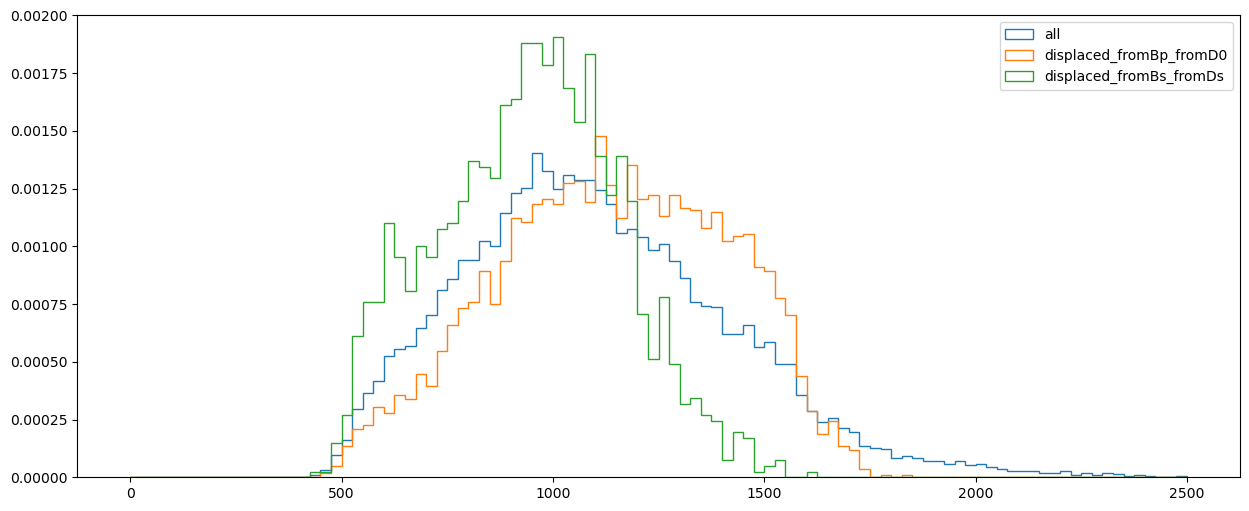

In [87]:
myrange=[0, 2500]
plt.hist(df_ws_isocut.Y_M, bins=100, 
         label= 'all', histtype='step', density=True, range=myrange);
plt.hist(df_ws_isocut.query("key == 'Xc_signal_Ypis_displaced_fromBp_fromD0'").Y_M, bins=100, 
         label= 'displaced_fromBp_fromD0', histtype='step', density=True, range=myrange)
plt.hist(df_ws_isocut.query("key == 'Xc_signal_Ypis_displaced_fromBs_fromDs'").Y_M, bins=100, 
         label= 'displaced_fromBs_fromDs', histtype='step', density=True, range=myrange)
# plt.hist(df_ws_isocut.query("key == 'Xc_background'").Y_M, bins=100, 
#          label= 'Xc_background', histtype='step', density=True, range=myrange)
# plt.hist(df_ws_isocut.query("key == 'Xc_signal_Ypis_nomatch_doubleCharm'").Y_M, bins=100, 
#          label= 'Xc_signal_Ypis_nomatch_doubleCharm', histtype='step', density=True, range=myrange)
plt.legend();

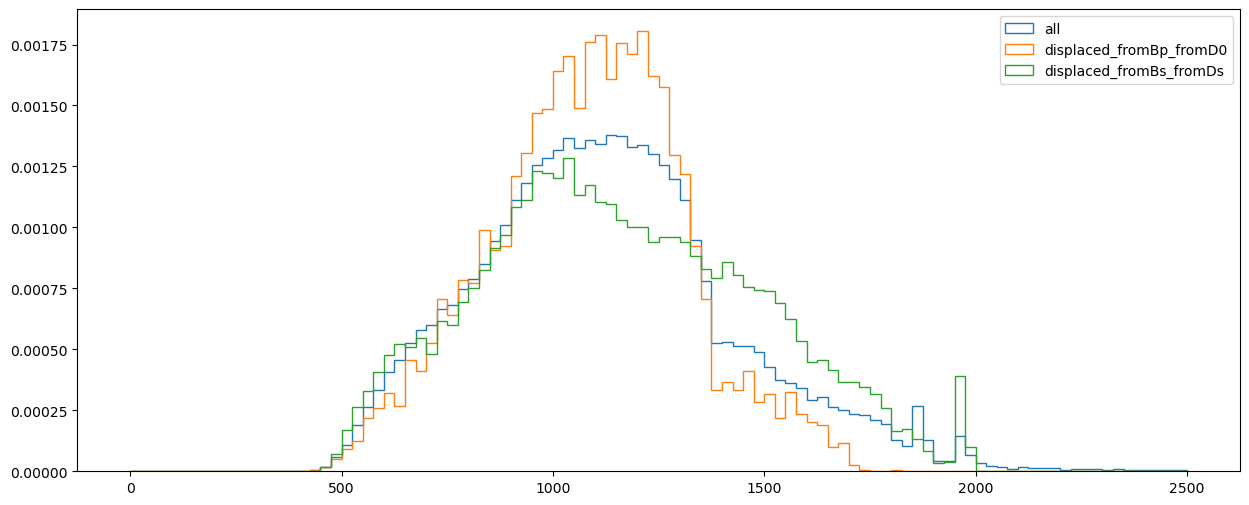

In [88]:
myrange=[0, 2500]
plt.hist(df_rs_isocut.Y_M, bins=100, 
         label= 'all', histtype='step', density=True, range=myrange);
plt.hist(df_rs_isocut.query("key == 'Xc_signal_Ypis_displaced_fromBp_fromD0'").Y_M, bins=100, 
         label= 'displaced_fromBp_fromD0', histtype='step', density=True, range=myrange)
plt.hist(df_rs_isocut.query("key == 'Xc_signal_Ypis_displaced_fromBs_fromDs'").Y_M, bins=100, 
         label= 'displaced_fromBs_fromDs', histtype='step', density=True, range=myrange)
# plt.hist(df_rs_isocut.query("key == 'Xc_background'").Y_M, bins=100, 
#          label= 'Xc_background', histtype='bar', density=True, range=myrange)
# plt.hist(df_rs_isocut.query("key == 'Xc_signal_Ypis_nomatch_doubleCharm'").Y_M, bins=100, 
#          label= 'Xc_signal_Ypis_nomatch_doubleCharm', histtype='step', density=True, range=myrange)
plt.legend();

In [123]:
def fom(df, c):
    df = df.query(f"BDT_Iso > {c}")
    nb_total = df.shape[0]
    cs = categ_groupby(df, "key", 1)[1]
    try:
        nb_signal = cs._get_value('Xc_signal_Ypis_displaced_fromBs_fromTau', 'count') 
    except:
        nb_signal = 0
    return nb_signal / np.sqrt(nb_total)

cutvals = np.arange(0, 0.5, 0.01)
fomvals = [ fom(df_rs, x) for x in cutvals]

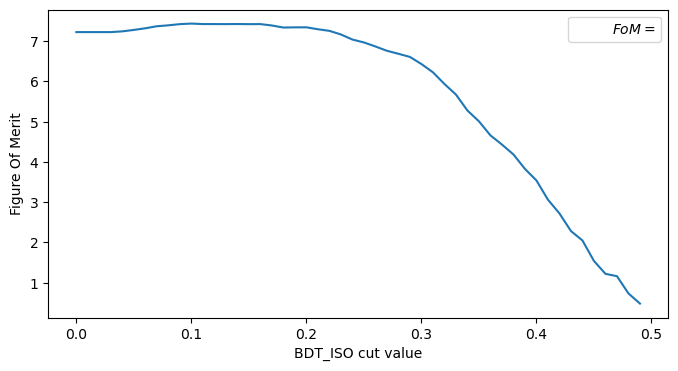

In [137]:
plt.figure(figsize=(8, 4))
plt.plot(cutvals, fomvals);
plt.xlabel("BDT_ISO cut value")
plt.ylabel("Figure Of Merit")
plt.plot([], [], ' ', label="$FoM=\frac{nbsignal}{\sqrt(nbtotal)}$")
plt.legend();